In [ ]:
!pip install yake

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tqdm import tqdm
import re
import ast


from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

import torch
from torch.utils.data import Dataset, DataLoader
from IPython.utils.sysinfo import encoding

from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Загрузка

In [ ]:
data = pd.read_csv('/content/data_no_keywords.csv')

In [ ]:
print(f"Всего статей: {len(data)}")
print(f"Тематик: {data['category'].nunique()}")
print("Тематики и количество статей")
data['category'].value_counts()

Всего статей: 13238
Тематик: 10
Тематики и количество статей


category
Бэкенд                         1796
AI и ML                        1781
Научпоп                        1651
Менеджмент                     1541
Администрирование              1483
Информационная безопасность    1468
Фронтенд                       1053
Маркетинг и контент             937
Геймдев                         934
Дизайн                          594
Name: count, dtype: int64

## Ключевые слова

In [ ]:
data['keywords'] = None

In [ ]:
kw_extractor = yake.KeywordExtractor(
    lan="ru",
    n=2,
    dedupLim=0.8,
    top=18,
    windowsSize=2,
    edginess=0.1
)


def extract_keywords(text):
    if pd.isna(text) or text == '':
        return []
    keywords = kw_extractor.extract_keywords(text)
    return [kw[0] for kw in keywords]

data['keywords'] = data['full_text'].apply(extract_keywords)

## Обработка

In [ ]:
def data_prep(text, title, topics, keywords):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()

    if isinstance(keywords, str):
        keywords = ast.literal_eval(keywords)
    if isinstance(topics, str):
        topics = ast.literal_eval(topics)

    cleaned_keywords = [word.replace(" ", "") for word in keywords]
    cleaned_topics = [topic.replace(" ", "") for topic in topics]

    keywords_str = " ".join(keywords)
    topics_str = " ".join(cleaned_topics)

    final_text = f'{title} [SEP] {topics_str} [SEP] {text} [SEP] {keywords_str}'
    return final_text

In [ ]:
data['full_text'] = data.apply(lambda x: data_prep(x['full_text'], x['title'], x['topics'], x['keywords']), axis=1)

In [ ]:
train_df, test_df = train_test_split(data, test_size=0.1, random_state=42, stratify=data['category'])

## Создание датасета

In [ ]:
class HabrDataset(Dataset):
  def __init__(self, text, labels, tokenizer, max_len=256):
    self.text = text
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.text)

  def __getitem__(self, idx):
    text = str(self.text[idx])
    label = self.labels[idx]

    encoding = self.tokenizer(
      text,
      padding='max_length',
      truncation=True,
      max_length=self.max_len,
      return_tensors='pt'
    )

    return {
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'labels': torch.tensor(label, dtype=torch.long)
    }

In [ ]:
def creating_dataloader(tokenizer, batch_size = 16, max_len=256):
  train_dataset = HabrDataset(train_texts, train_labels, tokenizer, max_len)
  test_dataset = HabrDataset(test_texts, test_labels, tokenizer, max_len)

  train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
  )

  val_loader = DataLoader(
      test_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=2
  )
  return train_loader, val_loader

In [ ]:
label_names = sorted(train_df['category'].unique())
num_labels = len(label_names)

label_to_id = {label: i for i, label in enumerate(label_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

train_texts = train_df['full_text'].tolist()
train_labels = [label_to_id[label] for label in train_df['category']]

test_texts = test_df['full_text'].tolist()
test_labels = [label_to_id[label] for label in test_df['category']]

## Training Loop

In [ ]:
class Triner:
    def __init__(self, model, optimizer, train_loader, val_loader,
      device, scheduler=None, label_names=None, save_path='best_model.pt',
      patience=3, delta=1e-4):

      self.model = model
      self.optimizer = optimizer
      self.train_loader = train_loader
      self.val_loader = val_loader
      self.device = device
      self.scheduler = scheduler
      self.label_names = label_names
      self.save_path = save_path

      self.patience = patience
      self.delta = delta
      self.early_stop_counter = 0

      self.model.to(device)

      self.f1_best = 0
      self.results = {
          "train_loss": [],
          "val_loss": [],
          "val_acc": [],
          "train_f1": [],
          "val_f1": []
      }

      self.best_labels = None
      self.best_preds = None
      self.last_labels = None
      self.last_preds = None

    def train_epoch(self):
      self.model.train()
      total_loss = 0

      for batch in tqdm(self.train_loader):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          self.optimizer.zero_grad()

          outputs = self.model(**batch)
          loss = outputs.loss
          loss.backward()

          self.optimizer.step()
          if self.scheduler:
              self.scheduler.step()

          total_loss += loss.item()

      return total_loss / len(self.train_loader)

    def eval_epoch(self):
      self.model.eval()
      total_loss = 0
      all_preds, all_labels = [], []

      for batch in tqdm(self.val_loader):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          with torch.no_grad():
              outputs = self.model(**batch)

          loss = outputs.loss
          logits = outputs.logits
          predictions = torch.argmax(logits, dim=-1)

          total_loss += loss.item()
          all_preds.extend(predictions.cpu().numpy())
          all_labels.extend(batch['labels'].cpu().numpy())

      acc = accuracy_score(all_labels, all_preds)
      f1 = f1_score(all_labels, all_preds, average='macro')

      self.last_labels = np.array(all_labels)
      self.last_preds = np.array(all_preds)

      return total_loss / len(self.val_loader), acc, f1

    def get_train_f1(self):
      """Вычисляет F1 на тренировочном датасете"""
      self.model.eval()
      all_preds, all_labels = [], []

      for batch in tqdm(self.train_loader, desc="Computing train F1"):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          with torch.no_grad():
              outputs = self.model(**batch)

          logits = outputs.logits
          predictions = torch.argmax(logits, dim=-1)

          all_preds.extend(predictions.cpu().numpy())
          all_labels.extend(batch['labels'].cpu().numpy())

      return f1_score(all_labels, all_preds, average='macro')

    def fit(self, epochs):
      for epoch in range(epochs):
          print(f'\nEpoch {epoch + 1}/{epochs}')

          train_loss = self.train_epoch()
          val_loss, acc_val, f1_val = self.eval_epoch()
          train_f1 = self.get_train_f1()

          self.results["train_loss"].append(train_loss)
          self.results["val_loss"].append(val_loss)
          self.results["val_acc"].append(acc_val)
          self.results["train_f1"].append(train_f1)
          self.results["val_f1"].append(f1_val)

          print(
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Accuracy: {acc_val:.4f} | "
              f"Train F1: {train_f1:.4f} | "
              f"Val F1: {f1_val:.4f}"
          )

          if f1_val > self.f1_best + self.delta:
              self.f1_best = f1_val
              self.early_stop_counter = 0

              self.best_labels = self.last_labels.copy()
              self.best_preds = self.last_preds.copy()

              model_filename = f'{f1_val:.4f}_{self.save_path}'

              torch.save(self.model.state_dict(), model_filename)
              print("Best model saved")

          else:
              self.early_stop_counter += 1
              if self.early_stop_counter >= self.patience:
                print("Early stopping")
                break

      print("\nTraining finished")

    def plot_history(self):
      epochs = range(1, len(self.results["train_loss"]) + 1)

      plt.figure(figsize=(14,5))

      plt.subplot(1,2,1)
      plt.plot(epochs, self.results["train_loss"], marker="o", label="Train loss")
      plt.plot(epochs, self.results["val_loss"], marker="o", label="Val loss")
      plt.title("Loss")
      plt.xlabel("Epoch")
      plt.ylabel("Loss")
      plt.legend()
      plt.grid()

      plt.subplot(1,2,2)
      plt.plot(epochs, self.results["train_f1"], marker="o", label="Train F1")
      plt.plot(epochs, self.results["val_f1"], marker="o", label="Validation F1")
      plt.title("F1 Score")
      plt.xlabel("Epoch")
      plt.ylabel("F1 Score")
      plt.legend()
      plt.grid()

      plt.show()

    def classification_report(self):
      print("\nClassification report:\n")
      print(classification_report(self.best_labels, self.best_preds, target_names=self.label_names))

      cm = confusion_matrix(self.best_labels, self.best_preds)

      plt.figure(figsize=(12,12))
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.label_names)
      disp.plot(xticks_rotation=90, cmap="Blues", values_format="d")
      plt.title("Confusion Matrix")
      plt.show()

# DeepPavlov/rubert-base-cased

In [ ]:
rubert_model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(rubert_model_name)

model_bert = AutoModelForSequenceClassification.from_pretrained(
    rubert_model_name,
    num_labels=num_labels
)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

## max_len = 256

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=model_bert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_BERT_keywords.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [03:13<00:00,  3.86it/s]


Train loss: 0.5103 | Val loss: 0.6731 | Accuracy: 0.7931 | Train F1: 0.8818 | Val F1: 0.7947
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [03:12<00:00,  3.86it/s]


Train loss: 0.3567 | Val loss: 0.6377 | Accuracy: 0.8082 | Train F1: 0.9528 | Val F1: 0.8110
Best model saved

Epoch 3/5


...

Train loss: 0.2183 | Val loss: 0.7825 | Accuracy: 0.7976 | Train F1: 0.9709 | Val F1: 0.8041

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [03:13<00:00,  3.86it/s]


Train loss: 0.1321 | Val loss: 0.8110 | Accuracy: 0.7968 | Train F1: 0.9853 | Val F1: 0.8041

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [03:12<00:00,  3.88it/s]

Train loss: 0.0839 | Val loss: 0.9613 | Accuracy: 0.7885 | Train F1: 0.9888 | Val F1: 0.7927
Early stopping

Training finished


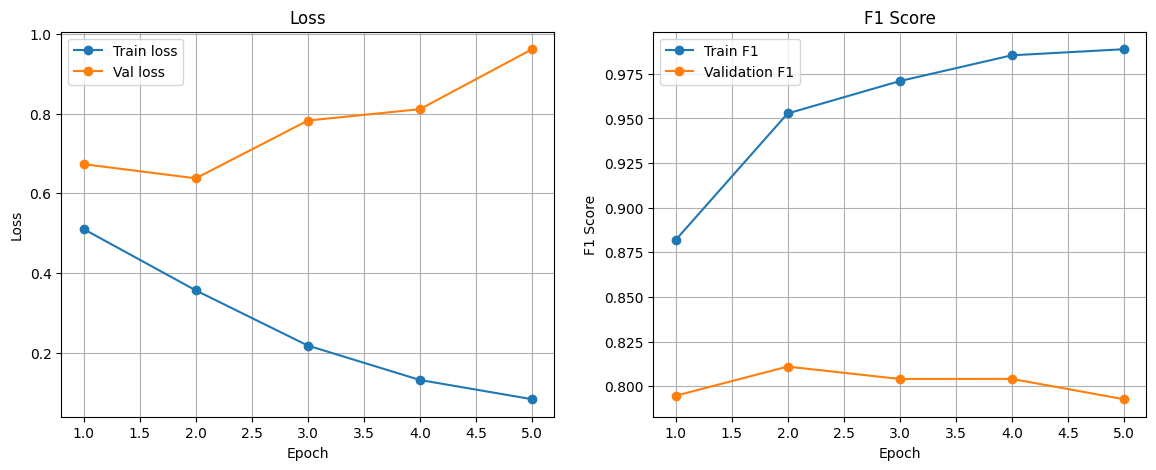

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.90      0.79      0.84       178
          Администрирование       0.84      0.75      0.79       148
                     Бэкенд       0.69      0.78      0.73       180
                    Геймдев       0.89      0.97      0.93        94
                     Дизайн       0.84      0.80      0.82        59
Информационная безопасность       0.84      0.85      0.84       147
        Маркетинг и контент       0.77      0.77      0.77        94
                 Менеджмент       0.75      0.77      0.76       154
                    Научпоп       0.88      0.88      0.88       165
                   Фронтенд       0.75      0.76      0.75       105

                   accuracy                           0.81      1324
                  macro avg       0.81      0.81      0.81      1324
               weighted avg       0.81      0.81      0.81      1324



<Figure size 1200x1200 with 0 Axes>

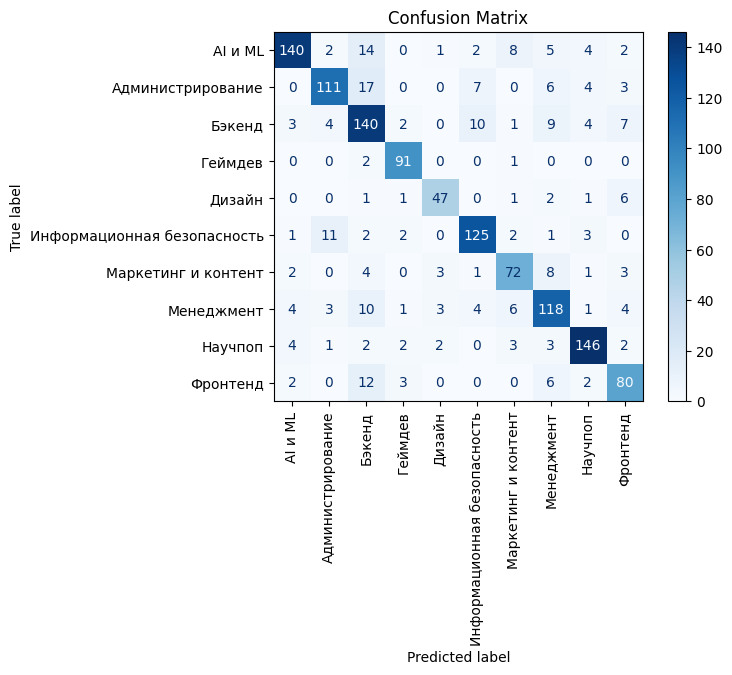

In [ ]:
trainer.classification_report()

# Tochka-AI/ruRoPEBert-classic-base-2k

In [ ]:
robert_model_name = "Tochka-AI/ruRoPEBert-classic-base-2k"
tokenizer = AutoTokenizer.from_pretrained(robert_model_name)

robert_model = AutoModelForSequenceClassification.from_pretrained(
    robert_model_name,
    num_labels=num_labels
)

config.json:   0%|          | 0.00/965 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/712M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: Tochka-AI/ruRoPEBert-classic-base-2k
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_embeddings.weight | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Co

## max_len = 384


In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 384)
optimizer = torch.optim.AdamW(robert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=robert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_robert_keywords.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [04:56<00:00,  2.51it/s]


Train loss: 0.9995 | Val loss: 0.7681 | Accuracy: 0.7659 | Train F1: 0.8104 | Val F1: 0.7655
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [04:56<00:00,  2.51it/s]


Train loss: 0.6271 | Val loss: 0.6980 | Accuracy: 0.7900 | Train F1: 0.8677 | Val F1: 0.7927
Best model saved

Epoch 3/5


...

Train loss: 0.4748 | Val loss: 0.7002 | Accuracy: 0.7764 | Train F1: 0.9151 | Val F1: 0.7874

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [04:57<00:00,  2.51it/s]


Train loss: 0.3343 | Val loss: 0.8596 | Accuracy: 0.7606 | Train F1: 0.9302 | Val F1: 0.7652

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [04:57<00:00,  2.50it/s]

Train loss: 0.2170 | Val loss: 0.9526 | Accuracy: 0.7583 | Train F1: 0.9772 | Val F1: 0.7703
Early stopping

Training finished


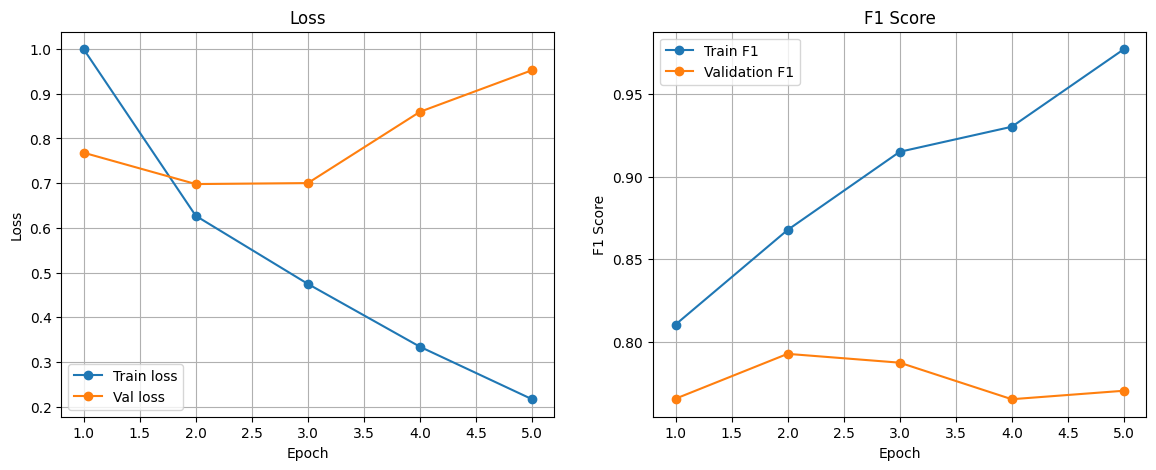

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.72      0.89      0.80       178
          Администрирование       0.78      0.78      0.78       148
                     Бэкенд       0.79      0.57      0.66       180
                    Геймдев       0.90      0.93      0.91        94
                     Дизайн       0.78      0.86      0.82        59
Информационная безопасность       0.77      0.92      0.84       147
        Маркетинг и контент       0.79      0.70      0.74        94
                 Менеджмент       0.78      0.71      0.75       154
                    Научпоп       0.93      0.83      0.88       165
                   Фронтенд       0.71      0.79      0.75       105

                   accuracy                           0.79      1324
                  macro avg       0.80      0.80      0.79      1324
               weighted avg       0.79      0.79      0.79      1324



<Figure size 1200x1200 with 0 Axes>

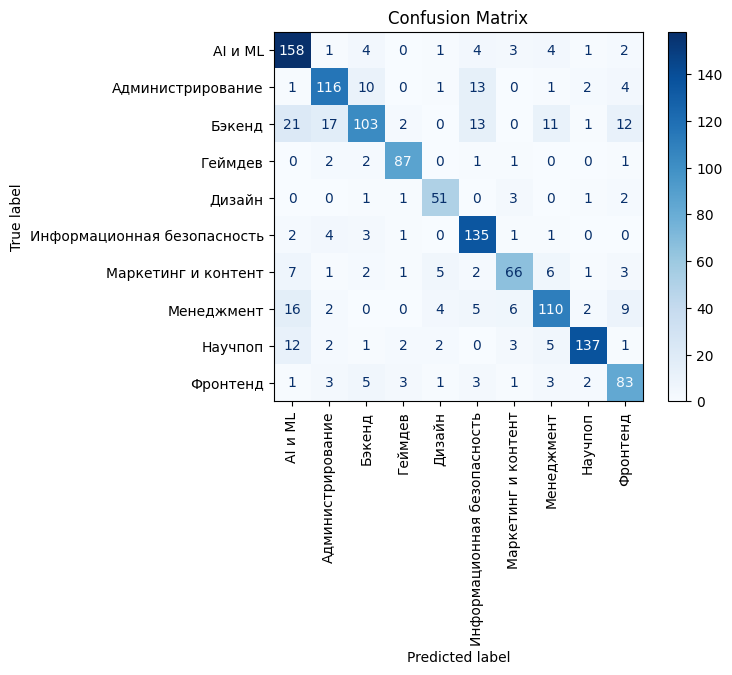

In [ ]:
trainer.classification_report()

# deepvk/RuModernBERT-base

In [ ]:
ru_modern_bert_model_name = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(robert_model_name)

ru_modern_bert_model = AutoModelForSequenceClassification.from_pretrained(
    ru_modern_bert_model_name,
    num_labels=num_labels
)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## max_len = 384

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 384)
optimizer = torch.optim.AdamW(ru_modern_bert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=ru_modern_bert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_ru_modern_bert_keywords.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [07:10<00:00,  1.73it/s]


Train loss: 0.7800 | Val loss: 0.6160 | Accuracy: 0.7915 | Train F1: 0.8725 | Val F1: 0.7949
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [07:08<00:00,  1.74it/s]


Train loss: 0.4218 | Val loss: 0.6291 | Accuracy: 0.8150 | Train F1: 0.9349 | Val F1: 0.8205
Best model saved

Epoch 3/5


...

Train loss: 0.2054 | Val loss: 0.7054 | Accuracy: 0.8044 | Train F1: 0.9804 | Val F1: 0.8142

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [07:10<00:00,  1.73it/s]


Train loss: 0.0889 | Val loss: 1.1611 | Accuracy: 0.7946 | Train F1: 0.9876 | Val F1: 0.8009

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [07:09<00:00,  1.74it/s]


Train loss: 0.0446 | Val loss: 0.9130 | Accuracy: 0.8210 | Train F1: 0.9935 | Val F1: 0.8261
Best model saved

Training finished


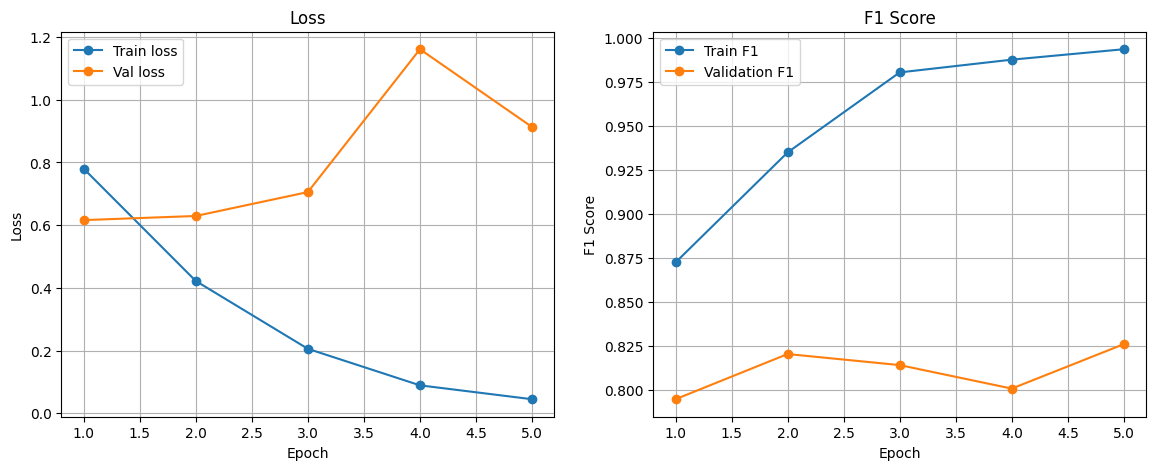

In [ ]:
trainer.plot_history()



Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.82      0.87      0.84       178
          Администрирование       0.82      0.82      0.82       148
                     Бэкенд       0.72      0.74      0.73       180
                    Геймдев       0.92      0.96      0.94        94
                     Дизайн       0.85      0.88      0.87        59
Информационная безопасность       0.83      0.93      0.88       147
        Маркетинг и контент       0.90      0.70      0.79        94
                 Менеджмент       0.72      0.73      0.73       154
                    Научпоп       0.89      0.87      0.88       165
                   Фронтенд       0.84      0.72      0.78       105

                   accuracy                           0.82      1324
                  macro avg       0.83      0.82      0.83      1324
               weighted avg       0.82      0.82      0.82      1324



<Figure size 1200x1200 with 0 Axes>

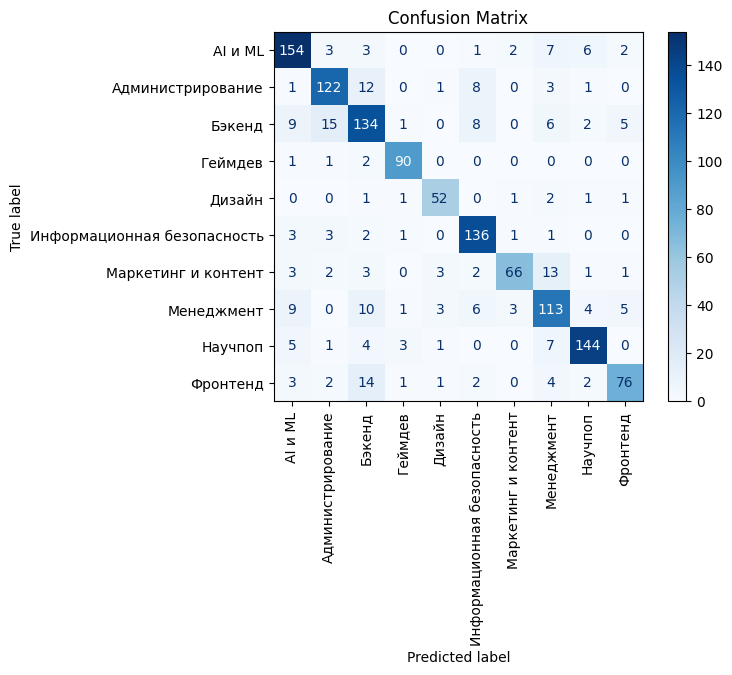

In [ ]:
trainer.classification_report()